In [1]:
import os
import json
import kagglehub
import numpy as np
import pandas as pd

#Procesamiento de Texto y Configuración
from textblob import TextBlob
from sklearn import set_config
set_config(display='diagram') 

# Visualización de Datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocesamiento y Pipelines
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

# Modelos de Regresión (Continuo)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, 
    Lars, BayesianRidge, SGDRegressor
)

# Modelos de Clasificación (Discreto)
from sklearn.linear_model import LogisticRegression

#Métricas de Evaluación
# Para Regresión
from sklearn.metrics import (
    r2_score, mean_absolute_error, 
    mean_absolute_percentage_error, mean_squared_error
)
# Para Clasificación
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
# Enviroment setup
set_config(display="diagram")
pd.set_option("display.max_columns", 50)
pd.set_option('display.float_format', lambda x: '%.8f' % x)

## Carga de datos

In [2]:
# Download latest version
path = kagglehub.dataset_download("datasnaek/youtube")

print("Path to dataset files:", path)

Path to dataset files: /Users/dafnezepedagonzalez/.cache/kagglehub/datasets/datasnaek/youtube/versions/24


In [3]:
# Listar los archivos para saber el nombre exacto
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

Archivos disponibles: ['GB_category_id.json', 'GBcomments.csv', 'US_category_id.json', 'USvideos.csv', 'GBvideos.csv', 'UScomments.csv']


In [4]:
csv_path_GBvideos= os.path.join(path, 'GBvideos.csv')
df_GBvideos = pd.read_csv(csv_path_GBvideos, on_bad_lines='skip')
csv_path_GBcomments= os.path.join(path, 'GBcomments.csv')
df_GBcomments = pd.read_csv(csv_path_GBcomments, on_bad_lines='skip')

## Data Wrangling

In [5]:
df_GBvideos.head(5)

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date
0,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.09000000
1,AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,24,this morning|interview|holly willoughby|philli...,494203,2651,1309,0,https://i.ytimg.com/vi/AqokkXoa7uE/default.jpg,13.09000000
2,YPVcg45W0z4,My DNA Test Results! I'm WHAT?!,emmablackery,24,emmablackery|emma blackery|emma|blackery|briti...,142819,13119,151,1141,https://i.ytimg.com/vi/YPVcg45W0z4/default.jpg,13.09000000
3,T_PuZBdT2iM,getting into a conversation in a language you ...,ProZD,1,skit|korean|language|conversation|esl|japanese...,1580028,65729,1529,3598,https://i.ytimg.com/vi/T_PuZBdT2iM/default.jpg,13.09000000
4,NsjsmgmbCfc,Baby Name Challenge!,Sprinkleofglitter,26,sprinkleofglitter|sprinkle of glitter|baby gli...,40592,5019,57,490,https://i.ytimg.com/vi/NsjsmgmbCfc/default.jpg,13.09000000


In [6]:
df_GBvideos.shape

(7993, 11)

In [7]:
df_GBvideos.describe()

,category_id,views,likes,dislikes,comment_total,date
count,7993.00000000,7993.00000000,7993.00000000,7993.00000000,7993.00000000,7993.00000000
mean,19.73827099,1110732.58864006,38859.66282998,1528.85887652,4991.63117728,16.08887401
std,7.17813231,3048739.98641341,109295.07652466,8176.70778757,26837.13551816,7.67817577
min,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.10000000
25%,17.00000000,108375.00000000,2580.00000000,71.00000000,308.00000000,10.10000000
50%,23.00000000,315194.00000000,9561.00000000,249.00000000,1038.00000000,16.10000000
75%,24.00000000,971221.00000000,31593.00000000,867.00000000,3327.00000000,21.10000000
max,29.00000000,58961407.00000000,2289911.00000000,192725.00000000,813322.00000000,30.09000000


In [8]:
df_GBcomments.rename(columns={'likes': 'likes_comment'}, inplace=True)
df_GBcomments.rename(columns={'replies': 'replies_comment'}, inplace=True)

In [9]:
df_GBcomments.head(5)

,video_id,comment_text,likes_comment,replies_comment
0,jt2OHQh0HoQ,It's more accurate to call it the M+ (1000) be...,0,0
1,jt2OHQh0HoQ,To be there with a samsung phone\n😂😂😂,1,0
2,jt2OHQh0HoQ,"Thank gosh, a place I can watch it without hav...",0,0
3,jt2OHQh0HoQ,What happened to the home button on the iPhone...,0,0
4,jt2OHQh0HoQ,Power is the disease. Care is the cure. Keep...,0,0


In [10]:
df_GBcomments.describe()

,likes_comment,replies_comment
count,718452.00000000,718452.00000000
mean,5.23745358,0.38125024
std,203.88389330,8.96795831
min,0.00000000,0.00000000
25%,0.00000000,0.00000000
50%,0.00000000,0.00000000
75%,0.00000000,0.00000000
max,60630.00000000,521.00000000


In [11]:
df_GBcomments.shape

(718452, 4)

In [12]:
csv_path_GB_category_id = os.path.join(path, 'GB_category_id.json')
with open(csv_path_GB_category_id, 'r') as f:
    data = json.load(f)

categories = []
for category in data['items']:
    categories.append({
        'category_id': int(category['id']),
        'name': category['snippet']['title']
    })

df_GB_category_id = pd.DataFrame(categories)
df_GB_category_id.head(5)

,category_id,name
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports


In [13]:
df_GBvideos.shape

(7993, 11)

In [14]:
# Unir Videos con Categorías (usando el ID)
# Esto añade la columna 'category_name' a videos
df_videos_con_cat = pd.merge(df_GBvideos, df_GB_category_id, on='category_id', how='left')

In [15]:
df_videos_con_cat.shape

(7993, 12)

In [16]:
#Agrupar por video para obtener estadísticas históricas
df_video_stats = df_videos_con_cat.groupby('video_id').agg({
    'date': 'nunique',  # ¿Cuántos días totales fue tendencia?
    'views': 'max',              # El pico máximo de vistas
    'likes': 'max',              # El pico máximo de likes
    'dislikes': 'max',           # El pico máximo de dislikes
    'comment_total': 'max',      # El pico máximo de comentarios
    'name': 'first',      # La categoría no cambia
    'title': 'first',
    'channel_title': 'first',
    'tags': 'first',
    'thumbnail_link': 'first'
}).reset_index()
# Renombrar para claridad
df_video_stats.rename(columns={'date': 'dias_en_tendencia_video',
                               'name': 'category_video',
                               'likes': 'likes_video',
                               'dislikes': 'dislikes_video',
                               'comment_total': 'comment_total_video',
                               'views': 'views_video',
                               'title':'title_video',
                               'tags': 'tags_video',
                               'thumbail_lik': 'thumbail_link_video'
                               }, inplace=True)
df_video_stats.sample(10)

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,category_video,title_video,channel_title,tags_video,thumbnail_link
450,GO6qs83CHpc,7,16514687,64455,7393,6953,News & Politics,Sneaky toddler steals Prince Harry's popcorn,The Royal Family Channel,prince harry|popcorn|poacher|girl|emily henson...,https://i.ytimg.com/vi/GO6qs83CHpc/default.jpg
1527,sWW9fP4v3Ew,8,48901,90,205,80,Sports,Alanyaspor 0-1 Fenerbahçe 17' Vincent Janssen,TESLACI,Alanyaspor 0-1 Fenerbahçe 17' Vincent Janssen,https://i.ytimg.com/vi/sWW9fP4v3Ew/default.jpg
940,Y2GVVC_cD_E,8,4675396,151922,2803,10422,Entertainment,73 Questions With Zac Efron | Vogue,Vogue,73 questions|celeb style|celebrity|zac efron|z...,https://i.ytimg.com/vi/Y2GVVC_cD_E/default.jpg
837,UkMZJrbCRdQ,6,380763,14670,853,1598,Science & Technology,Why Farming Is Broken (And Always Has Been),MinuteEarth,MinuteEarth|Minute Earth|MinutePhysics|Minute ...,https://i.ytimg.com/vi/UkMZJrbCRdQ/default.jpg
884,WDWlzSgBbx8,3,42128,1684,47,138,Gaming,TRIALS OF TRACTOR CANNON ft JustJason. Acid an...,The Destiny Fun Police,[none],https://i.ytimg.com/vi/WDWlzSgBbx8/default.jpg
979,Z4zXQV94foU,6,2415270,94890,1106,15844,People & Blogs,NO PLACE LIKE HOME!!,RomanAtwoodVlogs,Roman Atwood|Roman|Atwood|roman atwood vlogs|f...,https://i.ytimg.com/vi/Z4zXQV94foU/default.jpg
650,Nko0mn3r-eM,2,87510,3515,37,275,Pets & Animals,Golden Retriever is the Master of Self-Control,INSIDER,nellysnose|Nelly's Nose|golden retriever|self-...,https://i.ytimg.com/vi/Nko0mn3r-eM/default.jpg
705,Q0CbN8sfihY,12,32714551,674617,25022,113399,Entertainment,Star Wars: The Last Jedi Trailer (Official),Star Wars,star wars|the last jedi|trailer|official trail...,https://i.ytimg.com/vi/Q0CbN8sfihY/default.jpg
1209,fUffrvUjwCY,3,947615,48857,569,2687,Music,MACKLEMORE FEAT KESHA - GOOD OLD DAYS,Macklemore LLC,Mackelmore|Thrift Shop|Cant Hold Us|Can't Hold...,https://i.ytimg.com/vi/fUffrvUjwCY/default.jpg
87,1yYV9-KoSUM,6,3945097,151143,1868,5882,Music,MACKLEMORE FEAT KESHA - GOOD OLD DAYS (OFFICIA...,Macklemore LLC,Mackelmore|Thrift Shop|Cant Hold Us|Can't Hold...,https://i.ytimg.com/vi/1yYV9-KoSUM/default.jpg


In [17]:
df_video_stats.shape

(1736, 11)

### Nivel de interacción de viewrs vs comments

In [18]:
df_video_stats['users_interaction'] = df_video_stats['comment_total_video'] / (df_video_stats['views_video'] + 1)

In [19]:
# Crear variable objetivo: nivel de interacción usuarios
df_video_stats['users_interaction'] = pd.to_numeric(df_video_stats['users_interaction'], errors='coerce')
df_video_stats['users_interaction'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_video_stats['users_interaction'] = df_video_stats['users_interaction'].fillna(0)

Q1 = df_video_stats['users_interaction'].quantile(0.33)
Q3 = df_video_stats['users_interaction'].quantile(0.66)

# función que recibe un valor escalar
def interaction_level(value):
    if value < Q1:
        return 'Low'
    elif value < Q3:
        return 'Medium'
    else:
        return 'High'

df_video_stats['interaction_level'] = df_video_stats['users_interaction'].apply(interaction_level)
df_video_stats = df_video_stats.drop(columns=['users_interaction'])
df_video_stats[['interaction_level']].sample(10)


,interaction_level
713,Low
320,High
1085,Medium
1589,Medium
1382,Medium
1597,Medium
276,Medium
1466,Low
1224,Medium
798,High


Sentiment Analysis	Determines the emotional tone (polarity: -1 to 1) and objectivity (subjectivity: 0 to 1).	blob.sentiment

In [20]:
# Función para obtener solo la polaridad (sentimiento)
def get_sentiment(text):
    try:
        # Convertimos a string por si hay valores nulos o números
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

# Aplicamos al dataset original de comentarios
df_GBcomments['sentiment_score'] = df_GBcomments['comment_text'].apply(get_sentiment)

In [21]:
df_GBcomments.sample(10)

,video_id,comment_text,likes_comment,replies_comment,sentiment_score
310528,AoQMHzkj2x0,I LOVE THIS,0,0,0.50000000
257343,7KS2oJPzeZk,Yeah Daric won Agt,1,0,0.00000000
441643,a9Zi-RhcOGs,Wait where have I seen that guy before🤔...,0,1,0.00000000
522284,XE5D_Z1MmBA,Cancerous title and thumbnail,0,0,0.00000000
387198,T58NGMrUp0M,I SMELL FAKE NEWS: How the Americans like to b...,0,0,-0.50000000
206692,GXoigp2LFnY,"When you said Victoria nude, I was thinking Vi...",0,1,0.00000000
614287,MAaOyRot_2s,"Tom, your grandad got it the wrong way around....",6,0,-0.16666667
552195,AzNIUMW_G8M,My heart aches for you Alix... Saying this out...,0,0,0.23333333
56230,AybOx6RBdRw,Amazing vlog this is by far the best in the se...,0,0,0.65000000
515852,6l5P7jHUcjI,I'd need half a bottle of tequila for that.,0,0,-0.16666667


In [22]:
#Resumimos los comentarios
resumen_comentarios = df_GBcomments.groupby('video_id').agg({
    'comment_text': 'count',      # Total de renglones
    'likes_comment': 'mean',      # Promedio de likes por comentario
    'replies_comment':'mean',
    'sentiment_score': 'mean'        # Promedio de sentimiento
}).rename(columns={
    'likes_comment':'promedio_likes_por_comentario',
    'replies_comment':'promedio_replies_por_comentario',
    'comment_text': 'conteo_real_comentarios',
    'sentiment_score': 'sentimiento_promedio'})
resumen_comentarios.head(5)

,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio
video_id,,,,
--JinobXWPk,300,0.20000000,0.01333333,0.03773691
--y69Ui8xwM,291,3.87285223,0.98969072,0.17029046
-1fzGnFwz9M,200,8.75000000,0.20500000,0.13654245
-2hRYEFiPSA,700,1.45714286,0.09285714,0.23986667
-6Zc8Co2H3w,799,0.11000000,0.00375000,0.20554525


In [23]:
# Lo unimos al de videos (Cada video sigue siendo una sola fila)
df = pd.merge(df_video_stats, resumen_comentarios, on='video_id', how='left')

In [24]:
df.sample(10)

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,category_video,title_video,channel_title,tags_video,thumbnail_link,interaction_level,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio
594,LolP3Y7_Irs,8,334833,9562,446,368,Sports,BLINDFOLD GYMNASTICS CHALLENGE😱,Nile Wilson,nile wilson|nile wilson gymnastics|nile wilson...,https://i.ytimg.com/vi/LolP3Y7_Irs/default.jpg,Low,800.00000000,0.87500000,0.22000000,0.15884892
323,Ama7Dc1EgLM,5,843238,28715,1246,3067,Comedy,Visiting Your Crappy Hometown,CollegeHumor,Collegehumor|CH originals|comedy|sketch comedy...,https://i.ytimg.com/vi/Ama7Dc1EgLM/default.jpg,Medium,500.00000000,0.04400000,0.02400000,0.07775260
312,AWSNlL0xFm8,5,22829,98,5,32,People & Blogs,Cesc Fabregas finally admits to throwing pizza...,Eng Vids,Cesc|Fabregas|finally|admits|throwing|pizza|Fe...,https://i.ytimg.com/vi/AWSNlL0xFm8/default.jpg,Low,77.00000000,2.45454545,0.61038961,-0.03925528
1188,equByOb9j5E,9,1171972,2984,1195,2994,News & Politics,Burning device filmed on tube carriage at Pars...,Guardian Wires,parsons green|parsons green tube|parsons green...,https://i.ytimg.com/vi/equByOb9j5E/default.jpg,Medium,895.00000000,0.81675978,0.18659218,-0.00506917
908,Wq2nyYLv978,4,31852,2294,26,132,People & Blogs,YOUTUBE READY - CHATTY GRWM,Helen Anderson,helen anderson Silver hair Tattoos|Helen Ander...,https://i.ytimg.com/vi/Wq2nyYLv978/default.jpg,Medium,400.00000000,2.83000000,0.07000000,0.36137593
1208,fS5xHHqW-6E,3,427661,19658,234,604,Music,X Ambassadors - Ahead Of Myself,XAmbassadorsVEVO,Ambassadors|Ahead|Of|Myself|KIDinaKorner/Inter...,https://i.ytimg.com/vi/fS5xHHqW-6E/default.jpg,Low,300.00000000,0.21000000,0.03000000,0.34464371
1305,jXQitd7ahV4,8,902434,58844,591,1766,Music,Lost Kings - First Love (Official Video) ft. S...,WeAreLostKingsVEVO,Disruptor Records/RCA Records|Electronic|First...,https://i.ytimg.com/vi/jXQitd7ahV4/default.jpg,Low,798.00000000,0.22305764,0.01253133,0.27280659
1495,r912Kzj8uYg,7,98757,6221,73,719,Howto & Style,AUTUMN/FALL HAUL 2017 | sophdoesnails,sophdoesnails,grey hair|autumn haul|fall haul|autumn clothin...,https://i.ytimg.com/vi/r912Kzj8uYg/default.jpg,High,700.00000000,0.09571429,0.04000000,0.26945791
912,Wv3RpLvPasE,1,346221,3402,87,157,Music,MACKLEMORE FEAT OTIENO TERRY - LEVITATE,Macklemore LLC,macklemore|music|seattle|macklemore & ryan lew...,https://i.ytimg.com/vi/Wv3RpLvPasE/default.jpg,Low,89.00000000,8.08988764,0.51685393,0.19353187
1041,a6V-fKcW5YI,4,414510,1404,602,2451,Entertainment,"Woman brandishing a handgun, machete threatens...",FOX 11 Los Angeles,assault|Kardashian|boutique|DASH|handgun|mache...,https://i.ytimg.com/vi/a6V-fKcW5YI/default.jpg,High,400.00000000,0.11250000,0.00750000,-0.03490960


In [25]:
df.describe()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio
count,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1692.00000000,1692.00000000,1692.00000000,1692.00000000
mean,4.60426267,1098906.06278802,36468.51497696,1376.80414747,4531.63306452,424.60047281,6.05145744,0.47979560,0.15256586
std,2.30562880,3217177.32470670,106660.44285226,7062.17035149,23740.09892236,249.55224708,39.10342068,2.89146457,0.11138181
min,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,2.00000000,0.00000000,0.00000000,-0.16505556
25%,3.00000000,99108.00000000,2239.00000000,62.00000000,276.00000000,200.00000000,0.15500000,0.01875000,0.07215760
50%,5.00000000,295596.50000000,8432.00000000,226.00000000,906.00000000,400.00000000,0.50000000,0.08333333,0.13984750
75%,6.00000000,937798.25000000,28482.75000000,783.00000000,3027.50000000,600.00000000,2.75572963,0.39196311,0.22559532
max,12.00000000,58961407.00000000,2289911.00000000,192725.00000000,813322.00000000,1200.00000000,1311.50000000,114.00000000,0.60000000


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   video_id                         1736 non-null   object 
 1   dias_en_tendencia_video          1736 non-null   int64  
 2   views_video                      1736 non-null   int64  
 3   likes_video                      1736 non-null   int64  
 4   dislikes_video                   1736 non-null   int64  
 5   comment_total_video              1736 non-null   int64  
 6   category_video                   1732 non-null   object 
 7   title_video                      1736 non-null   object 
 8   channel_title                    1736 non-null   object 
 9   tags_video                       1736 non-null   object 
 10  thumbnail_link                   1736 non-null   object 
 11  interaction_level                1736 non-null   object 
 12  conteo_real_comentar

In [27]:
def freq_discrete(df, features):
    """
    Calcula y muestra tablas de frecuencias absolutas, relativas y acumuladas para variables categóricas.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que contiene las variables a analizar.
    features : list of str
        Lista con los nombres de las columnas categóricas a analizar.

    Descripción
    -----------
    Para cada variable en `features`, imprime su nombre y muestra una tabla con:
      - Frecuencia absoluta de cada categoría.
      - Frecuencia relativa (porcentaje) de cada categoría.
      - Frecuencia absoluta acumulada.
      - Frecuencia relativa acumulada.
    Los valores se formatean para mejor visualización.

    Ejemplo
    -------
    freq_discrete(df, ["color", "country"])
    """
    for feature in features:
        print(f"Feature: {feature}")
        abs_series = df[feature].value_counts(dropna=False)
        rel_series = df[feature].value_counts(dropna=False, normalize=True)
        freq = pd.DataFrame({"Absolute frequency": abs_series, "Relative frequency": rel_series})
        freq["Accumulated frequency"] = freq["Absolute frequency"].cumsum()
        freq["Accumulated %"] = freq["Relative frequency"].cumsum()
        freq["Absolute frequency"] = freq["Absolute frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Relative frequency"] = freq["Relative frequency"].map(lambda x: "{:,.2%}".format(x))
        freq["Accumulated frequency"] = freq["Accumulated frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Accumulated %"] = freq["Accumulated %"].map(lambda x: "{:,.2%}".format(x))
        display(freq)

In [28]:
ls_cont = df.select_dtypes(include='number').columns.to_list()
ls_disc = df.select_dtypes(include=object).columns.to_list()
ls_cont,ls_disc


(['dias_en_tendencia_video',
  'views_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'conteo_real_comentarios',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario',
  'sentimiento_promedio'],
 ['video_id',
  'category_video',
  'title_video',
  'channel_title',
  'tags_video',
  'thumbnail_link',
  'interaction_level'])

El conteo_real_comentarios_es la cuenta de cuantos comentarios habia de cada video en el data set de comentarios, no coincide con el comment_ total probablemente por que este limitado la cantidad de datos que trae o algo por el estilo

### EDA continuas

In [29]:
for col in ls_cont:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

#### EDA discretas

In [30]:
items_a_quitar = ["video_id", "title_video", "thumbnail_link"]
ls_disc = [x for x in ls_disc if x not in items_a_quitar]

In [31]:
for col in ls_disc:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

In [32]:
freq_discrete(df, ls_disc)

Feature: category_video


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
category_video,,,,
Entertainment,319,18.38%,319,18.38%
Music,280,16.13%,599,34.50%
Howto & Style,252,14.52%,851,49.02%
People & Blogs,245,14.11%,"1,096",63.13%
Sports,164,9.45%,"1,260",72.58%
Comedy,124,7.14%,"1,384",79.72%
Film & Animation,76,4.38%,"1,460",84.10%
News & Politics,68,3.92%,"1,528",88.02%
Gaming,65,3.74%,"1,593",91.76%


Feature: channel_title


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
channel_title,,,,
The Tonight Show Starring Jimmy Fallon,16,0.92%,16,0.92%
Vox,12,0.69%,28,1.61%
PointlessBlogVlogs,12,0.69%,40,2.30%
Jimmy Kimmel Live,11,0.63%,51,2.94%
The Late Late Show with James Corden,10,0.58%,61,3.51%
...,...,...,...,...
Roland S. Martin,1,0.06%,"1,732",99.77%
ZHUVEVO,1,0.06%,"1,733",99.83%
LTavvy,1,0.06%,"1,734",99.88%


Feature: tags_video


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
tags_video,,,,
[none],86,4.95%,86,4.95%
family|mom|mommy|baby|children|kids|mother|father|dad|son|daughter|home|young family|sacconejolys|video dairy|real life|reality tv|london|jonathan|joly|anna|saccone,9,0.52%,95,5.47%
James Corden|The Late Late Show|Colbert|late night|late night show|Stephen Colbert|Comedy|monologue|comedian|impressions|celebrities|carpool|karaoke|CBS|Late Late Show|Corden|joke|jokes|funny|funny video|funny videos|humor|celebrity|celeb|hollywood|famous,7,0.40%,102,5.88%
the real|daytime|talk show|women|tamera mowry|adrienne bailon|loni love|jeannie mai,5,0.29%,107,6.16%
The Late Show|Stephen Colbert|Colbert|Late Show|celebrities|late night|talk show|skits|bit|monologue|The Late Late Show|Late Late Show|letterman|david letterman|comedian|impressions|CBS|joke|jokes|funny|funny video|funny videos|humor|celebrity|celeb|hollywood|famous|James Corden|Corden|Comedy,5,0.29%,112,6.45%
...,...,...,...,...
Lisa Eldridge|Lisa Elridge|Lisa Eldrige|Makeup|Make-up|Make up|Tutorial|How To|Professional|Pro|Makeup artist|Beauty|cosmetics|best|top|makeupbylisaeldridge|lisa eldridge foundation|Cara Delevingne|Hollywood|Red Carpet|Rihanna|Kylie Cosmetics|Kim Kardashian|Fenty Beauty|Chrissy Teigen|Gigi Hadid|Kendal Jenner|Kardashian|Hailey Baldwin|KKW Beauty|chanel|lancome|bardot|claudia schiffer|supermodel|Vogue|Tarte|Tartecosmetics|Shape Tape|nicole kidman,1,0.06%,"1,732",99.77%
leighannsays|she in|shein|sheinside|haul|scam|is she in a scam|is shein a scam|is she in legit|is sheinlegit|romwe|scammer|zaful|try on haul|review|shein try on haul|the truth|truth about shein|cheap clothes scam|cheap chinese clothes|fast fashion|wtf|too good to be true|affordable clothes|fashion trends|womens fashion,1,0.06%,"1,733",99.83%
stephen a smith|colin kaepernick|kaepernick|first take|first take espn|espn first take|first take today|first take daily|first take nfl|first take colin kaepernick|snoop dogg|snoop|dogg|snoop dog|magic johnson|magic johnson lakers|snoop dogg colin kaepernick|stephen a. smith|stephen a smith nfl|colin kaepernick nfl|colin kaepernick qb|colin kaepernick protest|colin kaepernick nfl protest|nfl|football|football news|nfl news|ESPN,1,0.06%,"1,734",99.88%


Feature: interaction_level


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
interaction_level,,,,
High,590,33.99%,590,33.99%
Medium,573,33.01%,"1,163",66.99%
Low,573,33.01%,"1,736",100.00%


## Feature Engeneering

### Categorias de video aplicamos One Hot Encoder

In [33]:
# Instanciamos el codificador
# drop='first' para evitar la multicolinealidad en Regresión Lineal
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='error', dtype=np.int64)

categorias_codificadas = ohe.fit_transform(df[['category_video']])

df_ohe = pd.DataFrame(
    categorias_codificadas, 
    columns=ohe.get_feature_names_out(['category_video']),
    index=df.index
)
df_ohe

,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None
0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1732,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1733,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1734,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [34]:
print("Categoría eliminada (referencia):", ohe.categories_[0][0])

Categoría eliminada (referencia): Autos & Vehicles


In [35]:
#Unimos al dataframe original y eliminamos la columna de texto
df= pd.concat([df, df_ohe], axis=1).drop(columns=['category_video'])
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,channel_title,tags_video,thumbnail_link,interaction_level,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,Brave Wilderness,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,Medium,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,LilWiz,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,Medium,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,Simon's Cat,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,Low,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,LPAssociation,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,Medium,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,Screen Junkies,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,Medium,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),Screen Junkies,screenjunkies|screen junkies|screenjunkies new...,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,Medium,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,LaurDIY,DIY|do it yourself|how to|laurDIY|lauren riihi...,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,High,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,makeupbymichaelfinch,new york city|michael nyc,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,High,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",Movieclips Film Festivals & Indie Films,Advise|Annoy|Argue|Boss|Daughter|Father|Contro...,https://i.ytimg.com/vi/zujShZT8_go/default.jpg,Low,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0


### channel_title usamos Agrupación por "Fuerza del Canal" (Binning)

In [36]:
# Contamos las apariciones por canal
canal_counts = df['channel_title'].value_counts()

# Mapeamos ese conteo de vuelta al dataframe original
df['canal_frecuencia'] = df['channel_title'].map(canal_counts)

In [37]:
canal_counts

channel_title
The Tonight Show Starring Jimmy Fallon    16
Vox                                       12
PointlessBlogVlogs                        12
Jimmy Kimmel Live                         11
The Late Late Show with James Corden      10
                                          ..
Roland S. Martin                           1
ZHUVEVO                                    1
LTavvy                                     1
STOP/RESET                                 1
Molly Burke                                1
Name: count, Length: 1001, dtype: int64

In [38]:
# Definimos los umbrales usando percentiles
top_threshold = df['canal_frecuencia'].quantile(0.95)
mid_threshold = df['canal_frecuencia'].quantile(0.50)

# Función para categorizar
def categorizar_canal(frecuencia):
    if frecuencia >= top_threshold:
        return 'Top Tier'
    elif frecuencia >= mid_threshold:
        return 'Mid Tier'
    else:
        return 'Small Tier'

# Aplicamos el binning
df['fuerza_canal'] = df['canal_frecuencia'].apply(categorizar_canal)

In [39]:
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,channel_title,tags_video,thumbnail_link,interaction_level,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,canal_frecuencia,fuerza_canal
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,Brave Wilderness,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,Medium,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,6,Mid Tier
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,LilWiz,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,Medium,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,Small Tier
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,Simon's Cat,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,Low,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,4,Mid Tier
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,LPAssociation,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,Medium,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,Small Tier
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,Screen Junkies,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,Medium,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,Mid Tier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),Screen Junkies,screenjunkies|screen junkies|screenjunkies new...,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,Medium,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,Mid Tier
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,LaurDIY,DIY|do it yourself|how to|laurDIY|lauren riihi...,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,High,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,Mid Tier
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,makeupbymichaelfinch,new york city|michael nyc,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,High,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,7,Mid Tier
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",Movieclips Film Festivals & Indie Films,Advise|Annoy|Argue|Boss|Daughter|Father|Contro...,https://i.ytimg.com/vi/zujShZT8_go/default.jpg,Low,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,Small Tier


In [40]:
ohe_canal = OneHotEncoder(sparse_output=False, drop='first', dtype=int)
fuerza_encoded = ohe_canal.fit_transform(df[['fuerza_canal']])

# Crear el DataFrame con los nombres de las columnas 
df_fuerza = pd.DataFrame(
    fuerza_encoded, 
    columns=ohe_canal.get_feature_names_out(['fuerza_canal']),
    index=df.index
)

# Unimos y limpiamos
df = pd.concat([df, df_fuerza], axis=1)
# Ya no necesitamos ni el título original ni la frecuencia numérica
df.drop(columns=['channel_title', 'canal_frecuencia', 'fuerza_canal'], inplace=True)

In [41]:
#Se utilizó la categoría Mid Tier como base de referencia.
print("Categoría eliminada (referencia):", ohe_canal.categories_[0][0])

Categoría eliminada (referencia): Mid Tier


In [42]:
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,tags_video,thumbnail_link,interaction_level,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,Medium,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,Medium,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,Low,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,Medium,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,Medium,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),screenjunkies|screen junkies|screenjunkies new...,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,Medium,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,DIY|do it yourself|how to|laurDIY|lauren riihi...,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,High,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,new york city|michael nyc,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,High,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",Advise|Annoy|Argue|Boss|Daughter|Father|Contro...,https://i.ytimg.com/vi/zujShZT8_go/default.jpg,Low,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


### tags_video 

In [43]:
# Variable Continua: Cantidad de etiquetas
# Contamos cuántas palabras separadas por '|' hay. Si dice '[none]', ponemos 0.
df['cantidad_tags'] = df['tags_video'].apply(lambda x: len(str(x).split('|')) if x != '[none]' else 0)

# Variable Binaria: ¿Tiene etiquetas? 
# 1 si tiene contenido, 0 si no tiene nada ([none])
df['tiene_tags'] = df['tags_video'].apply(lambda x: 0 if x == '[none]' else 1)

# Variable Continua: Longitud del texto de los tags
# Esto mide qué tan descriptivas son las etiquetas en total
df['longitud_tags_texto'] = df['tags_video'].apply(lambda x: len(str(x)) if x != '[none]' else 0)

df.drop(columns=['tags_video'], inplace=True)
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,thumbnail_link,interaction_level,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,Medium,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,33,1,456
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,Medium,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,23,1,381
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,Low,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,44,1,445
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,Medium,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,4,1,58
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,Medium,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,15,1,239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,Medium,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,11,1,155
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,High,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,23,1,309
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,High,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,1,25
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",https://i.ytimg.com/vi/zujShZT8_go/default.jpg,Low,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,23,1,206


In [44]:
df.drop(columns=items_a_quitar,inplace=True)

In [45]:
ls_cont.append("cantidad_tags")
ls_cont.append("longitud_tags_texto")
df.sample(10)

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,interaction_level,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
1401,7,1134106,54315,2778,26137,High,700.00000000,0.18142857,0.05142857,-0.03423444,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,15,1,151
1210,7,3614568,109103,2591,14579,Medium,700.00000000,0.18714286,0.02000000,0.05965672,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,12,1,125
72,1,104581,3763,106,254,Medium,100.00000000,0.12000000,0.04000000,0.31500115,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,14,1,102
1223,7,1537037,13704,1420,1243,Low,700.00000000,6.54714286,2.01142857,0.09802513,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,29,1,433
823,5,49679,487,116,156,Medium,331.00000000,3.60120846,0.65558912,0.06271074,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,7,1,47
338,6,1107064,51042,535,1650,Low,600.00000000,0.13000000,0.02333333,0.10118999,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,18,1,371
949,3,1213210,65513,1833,3132,Medium,300.00000000,0.38666667,0.06333333,0.14393433,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,26,1,310
748,4,62505,4322,27,341,High,400.00000000,0.10250000,0.01750000,0.29357580,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,19,1,173
1143,3,2940791,89043,3993,5460,Low,300.00000000,0.68000000,0.02000000,0.14526673,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,37,1,220
316,6,678022,11182,297,1870,Medium,599.00000000,0.25666667,0.02500000,0.31281351,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,1,74


In [46]:
ls_bin=["category_video_Comedy","category_video_Education","category_video_Entertainment",
        "category_video_Film & Animation","category_video_Gaming","category_video_Howto & Style",
        "category_video_Music","category_video_News & Politics","category_video_People & Blogs",
        "category_video_Pets & Animals","category_video_Science & Technology","category_video_Sports",
        "category_video_Travel & Events","category_video_None","fuerza_canal_Small Tier",
        "fuerza_canal_Top Tier","tiene_tags"]
ls_cont,ls_bin

(['dias_en_tendencia_video',
  'views_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'conteo_real_comentarios',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario',
  'sentimiento_promedio',
  'cantidad_tags',
  'longitud_tags_texto'],
 ['category_video_Comedy',
  'category_video_Education',
  'category_video_Entertainment',
  'category_video_Film & Animation',
  'category_video_Gaming',
  'category_video_Howto & Style',
  'category_video_Music',
  'category_video_News & Politics',
  'category_video_People & Blogs',
  'category_video_Pets & Animals',
  'category_video_Science & Technology',
  'category_video_Sports',
  'category_video_Travel & Events',
  'category_video_None',
  'fuerza_canal_Small Tier',
  'fuerza_canal_Top Tier',
  'tiene_tags'])

## Cleaning Data

### DETECCIÓN Y REMOCIÓN DE VALORES EXTREMOS (OUTLIERS)

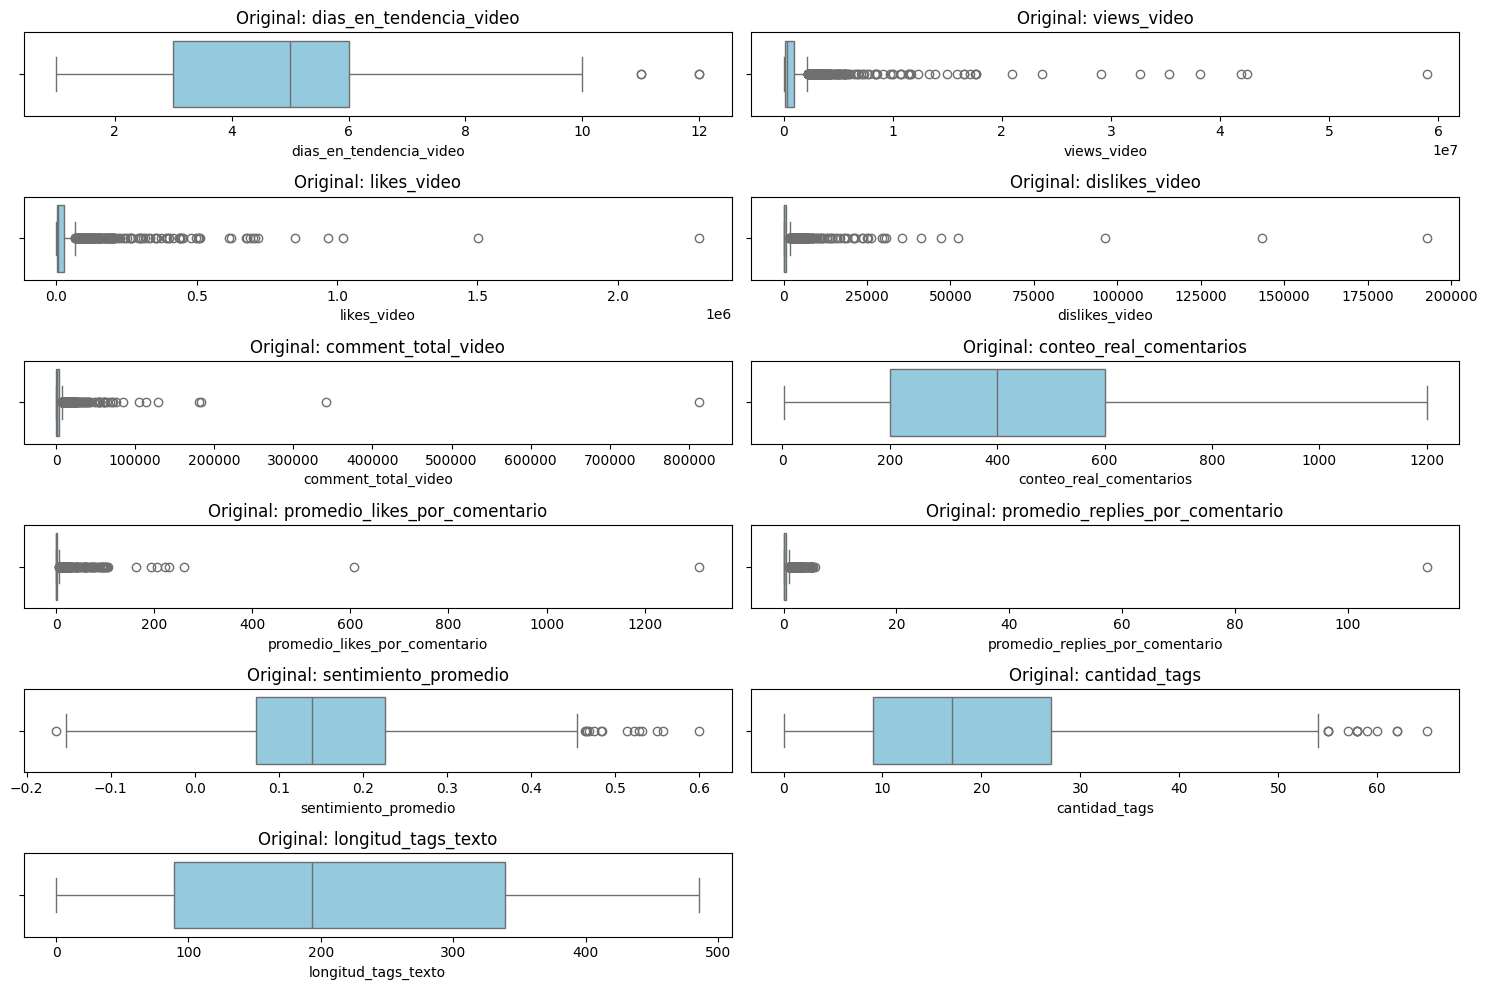

Conteo de Outliers por columna:
dislikes_video                     230
promedio_likes_por_comentario      210
comment_total_video                209
likes_video                        207
promedio_replies_por_comentario    200
views_video                        187
sentimiento_promedio                15
cantidad_tags                       13
dias_en_tendencia_video              4
conteo_real_comentarios              0
longitud_tags_texto                  0
dtype: int64


In [47]:
numeric_cols = ls_cont 
# Convertimos a float para que acepten los límites decimales del IQR
for col in numeric_cols:
    df[col] = df[col].astype('float64')

# Configuración de los cálculos IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df = df.reset_index(drop=True)

# Visualización ANTES de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Original: {col}')

plt.tight_layout()
plt.show()

# Mostrar el conteo de outliers 
outliers_mask = (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))
print("Conteo de Outliers por columna:")
print(outliers_mask.sum().sort_values(ascending=False))

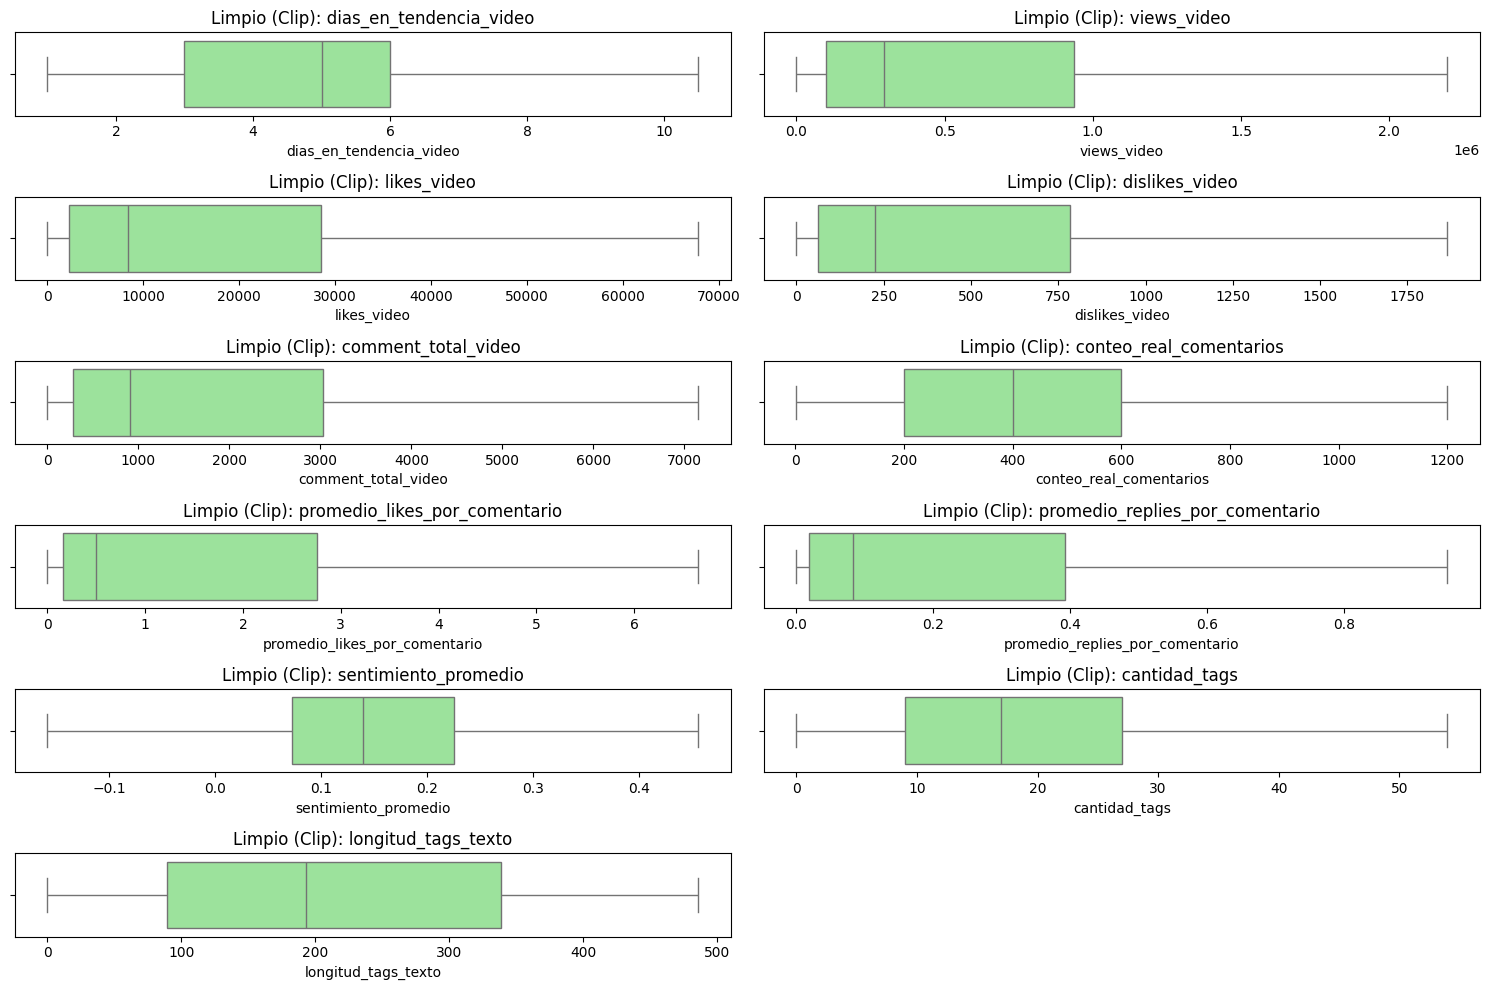

In [48]:
# Hacemos una copia para no alterar el original directamente
df_sin_outliers = df.copy()

#Aplicamos el tratamiento (Clip)
for col in numeric_cols:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df_sin_outliers[col] = df_sin_outliers[col].clip(lower, upper)

#Visualización DESPUÉS de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df_sin_outliers[col], color='lightgreen')
    plt.title(f'Limpio (Clip): {col}')

plt.tight_layout()
plt.show()

### DETECCIÓN Y REMOCIÓN DE VARIABLE POCO POBLADAS

In [49]:
missing_ratio = df_sin_outliers.isnull().mean()
missing_ratio.sort_values(ascending=False)

conteo_real_comentarios               0.02534562
promedio_likes_por_comentario         0.02534562
promedio_replies_por_comentario       0.02534562
sentimiento_promedio                  0.02534562
dias_en_tendencia_video               0.00000000
category_video_News & Politics        0.00000000
tiene_tags                            0.00000000
cantidad_tags                         0.00000000
fuerza_canal_Top Tier                 0.00000000
fuerza_canal_Small Tier               0.00000000
category_video_None                   0.00000000
category_video_Travel & Events        0.00000000
category_video_Sports                 0.00000000
category_video_Science & Technology   0.00000000
category_video_Pets & Animals         0.00000000
category_video_People & Blogs         0.00000000
category_video_Gaming                 0.00000000
category_video_Music                  0.00000000
category_video_Howto & Style          0.00000000
views_video                           0.00000000
category_video_Film 

In [50]:
low_populated_vars = missing_ratio[missing_ratio > 0.30].index.tolist()
low_populated_vars

[]

In [51]:
df.drop(columns=low_populated_vars, inplace=True)

#### DETECCIÓN Y REMOCIÓN DE VARIABLES UNITARIAS (UNARIAS)

In [52]:
list_columns = [
    col for col in df_sin_outliers.columns
    if df_sin_outliers[col].apply(lambda x: isinstance(x, list)).any()
]
unary_vars = [
    col for col in df_sin_outliers.columns
    if col not in list_columns and df_sin_outliers[col].nunique(dropna=True) == 1
]
unary_vars

[]

In [53]:
df_sin_outliers.drop(columns=unary_vars, inplace=True)
df_sin_outliers.head()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,interaction_level,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
0,3.00000000,1874297.00000000,46933.00000000,653.00000000,7154.75000000,Medium,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,33.00000000,1,456.00000000
1,6.00000000,47188.00000000,410.00000000,19.00000000,109.00000000,Medium,291.00000000,3.87285223,0.95178277,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,23.00000000,1,381.00000000
2,2.00000000,197531.00000000,7176.00000000,117.00000000,291.00000000,Low,200.00000000,6.65682408,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,44.00000000,1,445.00000000
3,7.00000000,159476.00000000,4995.00000000,31.00000000,368.00000000,Medium,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,4.00000000,1,58.00000000
4,8.00000000,2146662.00000000,52598.00000000,1381.00000000,7154.75000000,Medium,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,15.00000000,1,239.00000000


### DETECCIÓN Y TRATAMIENTO DE VALORES AUSENTES

In [54]:
df_sin_outliers.isna().sum()

dias_en_tendencia_video                 0
views_video                             0
likes_video                             0
dislikes_video                          0
comment_total_video                     0
interaction_level                       0
conteo_real_comentarios                44
promedio_likes_por_comentario          44
promedio_replies_por_comentario        44
sentimiento_promedio                   44
category_video_Comedy                   0
category_video_Education                0
category_video_Entertainment            0
category_video_Film & Animation         0
category_video_Gaming                   0
category_video_Howto & Style            0
category_video_Music                    0
category_video_News & Politics          0
category_video_People & Blogs           0
category_video_Pets & Animals           0
category_video_Science & Technology     0
category_video_Sports                   0
category_video_Travel & Events          0
category_video_None               

In [55]:
# Columnas numéricas 
num_cols = ls_cont 

# Imputer para numéricas (mediana)
imputer_num = SimpleImputer(strategy='median')

# Aplicar imputación
df_sin_outliers[num_cols] = imputer_num.fit_transform(df_sin_outliers[num_cols])

In [56]:
df_sin_outliers.isna().sum()

dias_en_tendencia_video                0
views_video                            0
likes_video                            0
dislikes_video                         0
comment_total_video                    0
interaction_level                      0
conteo_real_comentarios                0
promedio_likes_por_comentario          0
promedio_replies_por_comentario        0
sentimiento_promedio                   0
category_video_Comedy                  0
category_video_Education               0
category_video_Entertainment           0
category_video_Film & Animation        0
category_video_Gaming                  0
category_video_Howto & Style           0
category_video_Music                   0
category_video_News & Politics         0
category_video_People & Blogs          0
category_video_Pets & Animals          0
category_video_Science & Technology    0
category_video_Sports                  0
category_video_Travel & Events         0
category_video_None                    0
fuerza_canal_Sma

In [57]:
df_final = df_sin_outliers.copy()
df_final.drop(columns=["conteo_real_comentarios"], inplace=True)
df_final.sample(10)

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,interaction_level,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
242,3.00000000,98762.00000000,1611.00000000,18.00000000,97.00000000,Low,5.00448430,0.25560538,0.17425072,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0.00000000,0,0.00000000
1130,6.00000000,254529.00000000,9268.00000000,1864.50000000,4306.00000000,High,6.65682408,0.95178277,0.02801295,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,23.00000000,1,455.00000000
1176,5.00000000,247473.00000000,20651.00000000,227.00000000,2521.00000000,High,0.02400000,0.01600000,0.23525247,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,12.00000000,1,245.00000000
1552,4.00000000,759549.00000000,9985.00000000,193.00000000,942.00000000,Low,0.40500000,0.05250000,0.07150896,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,13.00000000,1,124.00000000
307,2.00000000,2195833.62500000,67848.37500000,1864.50000000,7154.75000000,Medium,0.08000000,0.01500000,0.14176173,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28.00000000,1,342.00000000
7,5.00000000,226101.00000000,2029.00000000,881.00000000,1025.00000000,High,0.17400000,0.00000000,0.07037153,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,22.00000000,1,232.00000000
184,5.00000000,0.00000000,0.00000000,0.00000000,0.00000000,Low,0.50000000,0.08333333,0.13984750,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0.00000000,0,0.00000000
702,3.00000000,15754.00000000,2216.00000000,23.00000000,250.00000000,High,2.64000000,0.14666667,0.26661392,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,31.00000000,1,317.00000000
389,4.00000000,15399.00000000,1066.00000000,11.00000000,68.00000000,Medium,0.70048309,0.07246377,0.38280533,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,27.00000000,1,276.00000000
346,3.00000000,697350.00000000,27556.00000000,483.00000000,5159.00000000,High,0.06666667,0.00666667,0.12104536,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,24.00000000,1,263.00000000


In [58]:
df_sin_outliers.describe()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
count,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000
mean,4.60195853,636345.29025058,19307.53665035,534.69412442,2068.77577765,423.97695853,1.75695570,0.24945521,0.15182883,0.07142857,0.02649770,0.18375576,0.04377880,0.03744240,0.14516129,0.16129032,0.03917051,0.14112903,0.01094470,0.02937788,0.09447005,0.00576037,0.00230415,0.39919355,0.05645161,18.32488479,0.95046083,213.88594470
std,2.29909810,723015.48654140,23178.76649516,639.88222398,2418.60822934,246.39793156,2.29061628,0.32503457,0.10864197,0.25761358,0.16065627,0.38739648,0.20466154,0.18989796,0.35236488,0.36790450,0.19405636,0.34825492,0.10407283,0.16891198,0.29256583,0.07569999,0.04796002,0.48987375,0.23085824,12.04599172,0.21705340,142.21293329
min,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,2.00000000,0.00000000,0.00000000,-0.15799898,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
25%,3.00000000,99108.00000000,2239.00000000,62.00000000,276.00000000,200.00000000,0.16000000,0.02000000,0.07366202,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,9.00000000,1.00000000,89.00000000
50%,5.00000000,295596.50000000,8432.00000000,226.00000000,906.00000000,400.00000000,0.50000000,0.08333333,0.13984750,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,17.00000000,1.00000000,193.00000000
75%,6.00000000,937798.25000000,28482.75000000,783.00000000,3027.50000000,600.00000000,2.63533006,0.37500000,0.22285759,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,27.00000000,1.00000000,339.00000000
max,10.50000000,2195833.62500000,67848.37500000,1864.50000000,7154.75000000,1200.00000000,6.65682408,0.95178277,0.45575190,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,54.00000000,1.00000000,486.00000000


## Targets

In [59]:
y_continuo= df_final.views_video
y_continuo.sample(10)

1330    112225.00000000
452     218281.00000000
1402   2195833.62500000
704     863340.00000000
315     457125.00000000
741      92135.00000000
746     103771.00000000
156     468484.00000000
271     227207.00000000
1142    256673.00000000
Name: views_video, dtype: float64

## Modelado variable objetivo continua

### Segmentación de sets

In [60]:
X = df_final.drop(columns=['views_video'])
y = y_continuo

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [62]:
ls_cont.remove("conteo_real_comentarios")
ls_cont.remove("views_video")

In [63]:
ls_cont,ls_bin

(['dias_en_tendencia_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario',
  'sentimiento_promedio',
  'cantidad_tags',
  'longitud_tags_texto'],
 ['category_video_Comedy',
  'category_video_Education',
  'category_video_Entertainment',
  'category_video_Film & Animation',
  'category_video_Gaming',
  'category_video_Howto & Style',
  'category_video_Music',
  'category_video_News & Politics',
  'category_video_People & Blogs',
  'category_video_Pets & Animals',
  'category_video_Science & Technology',
  'category_video_Sports',
  'category_video_Travel & Events',
  'category_video_None',
  'fuerza_canal_Small Tier',
  'fuerza_canal_Top Tier',
  'tiene_tags'])

In [64]:
#Definición de Escaladores y Modelos
escaladores = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust':RobustScaler()
}

modelos = {
    'Lineal': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Lars': Lars(),
    'Bayesiana': BayesianRidge(),
    'SGD': SGDRegressor(max_iter=1000, tol=1e-3) # El optimizador rápido 
}

resultados_cv = []
# Solo escalamos las continuas, las binarias (0/1) pasan directo
for esc_nombre, esc in escaladores.items():
    prepro = ColumnTransformer(transformers=[
        ('num', esc, ls_cont),
        ('bin', 'passthrough', ls_bin)
    ])
    
    for mod_nombre, mod in modelos.items():
        pipeline = Pipeline([('prepro', prepro), ('regresor', mod)])
        
        # Cross-Validation
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=4, scoring='r2')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std() # Qué tanto varían los resultados
        
        # Entrenamiento final para métricas de Test
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        r2_test = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        resultados_cv.append({
            'Configuración': f"{mod_nombre} ({esc_nombre})",
            'CV R2 Promedio': cv_mean,
            'CV R2 Desv. Est.': cv_std,
            'R2 Test': r2_test,
            'MAE Test': mae,
            'RMSE Test': rmse
        })

df_final_res = pd.DataFrame(resultados_cv).sort_values(by='CV R2 Promedio', ascending=False)
df_final_res

,Configuración,CV R2 Promedio,CV R2 Desv. Est.,R2 Test,MAE Test,RMSE Test
5,Bayesiana (Standard),0.81532977,0.01245904,0.82351729,195600.40926387,314309.32057653
19,Bayesiana (Robust),0.81529748,0.01257811,0.82351649,195651.12448091,314310.02559473
15,Ridge (Robust),0.81505414,0.01318670,0.82360077,195839.09456809,314234.96677780
1,Ridge (Standard),0.81504528,0.01318636,0.82360621,195840.46767715,314230.12532352
8,Ridge (MinMax),0.81500226,0.01311340,0.82350641,196141.47114155,314319.00505925
9,Lasso (MinMax),0.81466689,0.01371157,0.82356297,195841.05215732,314268.63502271
16,Lasso (Robust),0.81466667,0.01371124,0.82356351,195841.45063405,314268.15790895
2,Lasso (Standard),0.81466667,0.01371120,0.82356360,195841.59025713,314268.07858615
7,Lineal (MinMax),0.81466361,0.01372001,0.82356304,195840.71609513,314268.57759305
0,Lineal (Standard),0.81466361,0.01372001,0.82356304,195840.71609513,314268.57759305


### GridSearch

En este caso ocupe Lasso con Min Max Scaler pero creo podemos elegir otro modelo aun mejor

In [65]:
pipeline_final = Pipeline([
    ('prepro', ColumnTransformer(transformers=[
        ('num', MinMaxScaler(), ls_cont),
        ('bin', 'passthrough', ls_bin)
    ])),
    ('regresor', Lasso(max_iter=10000))
])
# Rango exacto del for: de 0.1 a 10.0 (100 pasos)
# i/100 para i in range(10, 1010, 10) es equivalente a:
alphas_manuales = np.linspace(0.1, 10.0, 100)

#Ajustamos la malla de búsqueda (param_grid)
param_grid = {
    'regresor__alpha': alphas_manuales
}

# Configuramos el GridSearchCV
# cv=4 y n_jobs=-1 para velocidad
grid_lasso = GridSearchCV(
    pipeline_final, 
    param_grid, 
    cv=4, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

# Entrenamos
grid_lasso.fit(X_train, y_train)

df_res_automatico = pd.DataFrame(grid_lasso.cv_results_)
df_res_final = df_res_automatico[['param_regresor__alpha', 'mean_test_score', 'std_test_score']]
df_res_final.columns = ['alpha', 'r2_mean', 'r2_std']

df_res_final


Fitting 4 folds for each of 100 candidates, totalling 400 fits


,alpha,r2_mean,r2_std
0,0.10000000,0.81466394,0.01371916
1,0.20000000,0.81466427,0.01371832
2,0.30000000,0.81466460,0.01371747
3,0.40000000,0.81466493,0.01371663
4,0.50000000,0.81466526,0.01371578
...,...,...,...
95,9.60000000,0.81469669,0.01364339
96,9.70000000,0.81469701,0.01364261
97,9.80000000,0.81469733,0.01364183
98,9.90000000,0.81469764,0.01364106


In [66]:
print(f"\nMejor Alpha: {grid_lasso.best_params_}")


Mejor Alpha: {'regresor__alpha': np.float64(10.0)}


In [67]:
# Definimos el Pipeline con el ganador absoluto
mejor_pipe = Pipeline([
    ('prepro', ColumnTransformer(transformers=[
        ('num', StandardScaler(), ls_cont),
        ('bin', 'passthrough', ls_bin)
    ])),
    ('regresor', BayesianRidge())
])

# Entrenamos con el set de entrenamiento completo
mejor_pipe.fit(X_train, y_train)

# Extraemos la importancia de las variables (Coeficientes)
nombres_variables = ls_cont + ls_bin
pesos = mejor_pipe.named_steps['regresor'].coef_

df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Impacto': pesos
}).sort_values(by='Impacto', ascending=False)

# Mostramos las 10 que más suben las vistas
print("Top Variables que aumentan las vistas:")
print(df_importancia.head(10))

Top Variables que aumentan las vistas:
                           Variable         Impacto
1                       likes_video 369771.15825046
2                    dislikes_video 284445.88780106
18    category_video_Pets & Animals 133532.74891133
12  category_video_Film & Animation 103109.73287489
8               longitud_tags_texto  46971.93395594
23          fuerza_canal_Small Tier  37916.84367586
0           dias_en_tendencia_video  29678.10268325
24            fuerza_canal_Top Tier  27703.95088156
20            category_video_Sports  21296.37493286
3               comment_total_video  14285.23699624


## Modelado variable objetivo discreta

In [68]:
df_final.sample()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,interaction_level,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
354,1.00000000,469853.00000000,10125.00000000,359.00000000,2400.00000000,High,4.36000000,0.46000000,0.02980300,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29.00000000,1,417.00000000


In [69]:
def level_to_numeric(level):
    mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    return mapping.get(level, -1) 

df_final['interaction_level'] = df_final['interaction_level'].apply(level_to_numeric)
df_final.sample(10)

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,interaction_level,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
980,2.00000000,66022.00000000,2280.00000000,99.00000000,160.00000000,1,6.65682408,0.11734694,0.17396807,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,41.00000000,1,446.00000000
1328,3.00000000,179801.00000000,7859.00000000,38.00000000,1270.00000000,2,0.01333333,0.00000000,0.03998234,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,11.00000000,1,129.00000000
1091,7.00000000,2195833.62500000,67848.37500000,1864.50000000,7154.75000000,1,1.05714286,0.12571429,0.20584190,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,36.00000000,1,377.00000000
346,3.00000000,697350.00000000,27556.00000000,483.00000000,5159.00000000,2,0.06666667,0.00666667,0.12104536,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,24.00000000,1,263.00000000
1117,6.00000000,1598473.00000000,40569.00000000,735.00000000,5044.00000000,1,0.16000000,0.02333333,0.12156323,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,31.00000000,1,453.00000000
1313,5.00000000,281592.00000000,12750.00000000,297.00000000,2515.00000000,2,5.17400000,0.62400000,0.08331170,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,10.00000000,1,76.00000000
146,7.00000000,462950.00000000,10627.00000000,649.00000000,1191.00000000,1,2.26428571,0.87428571,0.07013967,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,41.00000000,1,459.00000000
1314,4.00000000,146695.00000000,4567.00000000,56.00000000,534.00000000,1,0.05000000,0.00750000,0.07987843,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,29.00000000,1,369.00000000
984,2.00000000,115782.00000000,4393.00000000,65.00000000,434.00000000,1,0.22000000,0.13500000,0.04191667,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,26.00000000,1,343.00000000
469,4.00000000,17348.00000000,197.00000000,37.00000000,74.00000000,1,3.58878505,0.95178277,0.06615909,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,3.00000000,1,30.00000000


In [70]:
X = df_final.drop(columns=['interaction_level'])
y = df_final['interaction_level']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [72]:
y_test.sample(5)

1179    2
561     2
578     2
143     1
102     1
Name: interaction_level, dtype: int64

In [79]:
#Definición de Escaladores y Modelos
escaladores = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust':RobustScaler()
}

modelos = {
    'Lineal': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Lars': Lars(),
    'Bayesiana': BayesianRidge(),
    'SGD': SGDRegressor(max_iter=1000, tol=1e-3) # El optimizador rápido 
}
resultados_cv_cont = []
# Solo escalamos las continuas, las binarias (0/1) pasan directo
for esc_nombre, esc in escaladores.items():
    prepro = ColumnTransformer(transformers=[
        ('num', esc, ls_cont),
        ('bin', 'passthrough', ls_bin)
    ])
    
    for mod_nombre, mod in modelos.items():
        pipeline = Pipeline([('prepro', prepro), ('regresor', mod)])
        
        # Cross-Validation
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=4, scoring='r2')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std() # Qué tanto varían los resultados
        
        # Entrenamiento final para métricas de Test
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        r2_test = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        resultados_cv_cont.append({
            'Configuración': f"{mod_nombre} ({esc_nombre})",
            'CV R2 Promedio': cv_mean,
            'CV R2 Desv. Est.': cv_std,
            'R2 Test': r2_test,
            'MAE Test': mae,
            'RMSE Test': rmse
        })

# Protección: evitar error si no se generaron resultados
if len(resultados_cv_cont) == 0:
    print("No se generaron resultados. Revisa que el bucle se ejecute correctamente.")
else:
    df_final_res_cont = pd.DataFrame(resultados_cv_cont).sort_values(by='CV R2 Promedio', ascending=False)
    df_final_res_cont.head()

In [74]:
df_final_res_cont

,Configuración,CV R2 Promedio,CV R2 Desv. Est.,R2 Test,MAE Test,RMSE Test
5,Bayesiana (Standard),0.26979062,0.01020407,0.33754374,0.56537192,0.66422263
19,Bayesiana (Robust),0.26958866,0.01023377,0.33791500,0.56544326,0.66403648
8,Ridge (MinMax),0.26749861,0.00898194,0.34239838,0.56351294,0.66178437
15,Ridge (Robust),0.26739865,0.00687563,0.34475581,0.56204659,0.66059709
1,Ridge (Standard),0.26732628,0.00677497,0.34486083,0.56197509,0.66054415
12,Bayesiana (MinMax),0.26707211,0.01035421,0.33994970,0.56493050,0.66301535
6,SGD (Standard),0.26675158,0.01555477,0.32546787,0.56887999,0.67024933
0,Lineal (Standard),0.26663465,0.00666095,0.34696736,0.55984814,0.65948134
14,Lineal (Robust),0.26663465,0.00666095,0.34696736,0.55984814,0.65948134
7,Lineal (MinMax),0.26663465,0.00666095,0.34696736,0.55984814,0.65948134


### Mejores parametros

Se hizo con el modelo Ridge y Escalamiento MinMax ya que BayesianRidge no permite parametros

In [80]:
pipeline_final = Pipeline([
    ('prepro', ColumnTransformer(transformers=[
        ('num', MinMaxScaler(), ls_cont),
        ('bin', 'passthrough', ls_bin)
    ])),
    ('regresor', Ridge(max_iter=10000))
])
# Rango exacto del for: de 0.1 a 10.0 (100 pasos)
# i/100 para i in range(10, 1010, 10) es equivalente a:
alphas_manuales = np.linspace(0.1, 10.0, 100)

#Ajustamos la malla de búsqueda (param_grid)
param_grid = {
    'regresor__alpha': alphas_manuales
}

# Configuramos el GridSearchCV
# cv=4 y n_jobs=-1 para velocidad
grid_ridge = GridSearchCV(
    pipeline_final, 
    param_grid, 
    cv=4,
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

# Entrenamos
grid_ridge.fit(X_train, y_train)
score = grid_ridge.best_score_
print(f"\nMejor Alpha: {grid_ridge.best_params_} con R2 CV: {score}")


df_res_automatico = pd.DataFrame(grid_ridge.cv_results_)
df_res_final = df_res_automatico[['param_regresor__alpha', 'mean_test_score', 'std_test_score']]
df_res_final.columns = ['alpha', 'r2_mean', 'r2_std']

df_res_final

Fitting 4 folds for each of 100 candidates, totalling 400 fits

Mejor Alpha: {'regresor__alpha': np.float64(1.0)} con R2 CV: 0.267498607951589


,alpha,r2_mean,r2_std
0,0.10000000,0.26682213,0.00689935
1,0.20000000,0.26696987,0.00712922
2,0.30000000,0.26709427,0.00736138
3,0.40000000,0.26720033,0.00759649
4,0.50000000,0.26728965,0.00783292
...,...,...,...
95,9.60000000,0.24605514,0.01556337
96,9.70000000,0.24574229,0.01557534
97,9.80000000,0.24542979,0.01558677
98,9.90000000,0.24511768,0.01559768


In [81]:
# Definimos el Pipeline con el ganador absoluto
pipeline_mejorado_ridge = Pipeline([
    ('prepro', ColumnTransformer(transformers=[
        ('num', MinMaxScaler(), ls_cont),
        ('bin', 'passthrough', ls_bin)
    ])),
    ('regresor', Ridge(max_iter=10000))
])

# Entrenamos con el set de entrenamiento completo
pipeline_mejorado_ridge.fit(X_train, y_train)
# Extraemos la importancia de las variables (Coeficientes)
nombres_variables = ls_cont + ls_bin
pesos = pipeline_mejorado_ridge.named_steps['regresor'].coef_

df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Impacto': pesos
}).sort_values(by='Impacto', ascending=False)

# Top 10 variables con mayor impacto positivo
print(df_importancia.head(10))

                          Variable    Impacto
3              comment_total_video 2.22475092
13           category_video_Gaming 0.42309096
17   category_video_People & Blogs 0.39546593
14    category_video_Howto & Style 0.36408017
10        category_video_Education 0.31471098
16  category_video_News & Politics 0.29729385
9            category_video_Comedy 0.25315705
6             sentimiento_promedio 0.20689121
11    category_video_Entertainment 0.14696882
25                      tiene_tags 0.11851179
